In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Regional Sales Dataset.xlsx", sheet_name=None)
df

{'Sales Orders':         OrderNumber  OrderDate  Customer Name Index      Channel  \
 0       SO - 000225 2014-01-01                  126    Wholesale   
 1      SO - 0003378 2014-01-01                   96  Distributor   
 2      SO - 0005126 2014-01-01                    8    Wholesale   
 3      SO - 0005614 2014-01-01                   42       Export   
 4      SO - 0005781 2014-01-01                   73    Wholesale   
 ...             ...        ...                  ...          ...   
 64099  SO - 0007573 2018-02-28                   74    Wholesale   
 64100  SO - 0007706 2018-02-28                   51       Export   
 64101  SO - 0007718 2018-02-28                  136  Distributor   
 64102  SO - 0008084 2018-02-28                  158  Distributor   
 64103  SO - 0008654 2018-02-28                   22  Distributor   
 
       Currency Code Warehouse Code  Delivery Region Index  \
 0               USD         AXW291                    364   
 1               USD         A

In [4]:
df_orders = df['Sales Orders']
df_customers = df['Customers']
df_products = df['Products']
df_regions = df['Regions']
df_state_reg = df['State Regions']
df_budget = df['2017 Budgets']

In [5]:
df_orders.head(2)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918


In [6]:
df_customers.head(2)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group


In [7]:
df_budget.head(2)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565


In [8]:
df_products.head(2)

,Index,Product Name
0,1,Product 1
1,2,Product 2


In [9]:
df_regions.head(2)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago


In [10]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [11]:
print(f'Shape of df_orders : {df_orders.shape}')
print(f'Shape of df_customers : {df_customers.shape}')
print(f'Shape of df_regions : {df_regions.shape}')
print(f'Shape of df_products : {df_products.shape}')
print(f'Shape of df_state_reg : {df_state_reg.shape}')
print(f'Shape of df_budget : {df_budget.shape}')

Shape of df_orders : (64104, 12)
Shape of df_customers : (175, 2)
Shape of df_regions : (994, 15)
Shape of df_products : (30, 2)
Shape of df_state_reg : (49, 3)
Shape of df_budget : (30, 2)


In [12]:
df_state_reg.columns = df_state_reg.iloc[0]
df_state_reg = df_state_reg.iloc[1:]

df_state_reg.reset_index(drop=True, inplace=True)

df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [13]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [14]:
df_budget.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [15]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [16]:
df_orders.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [17]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [18]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [19]:
#Cleaning columns

In [20]:
df_orders.columns = df_orders.columns.str.lower()

In [21]:
df_orders.columns = df_orders.columns.str.replace(' ', '_')

In [22]:
df_orders.drop(columns= 'currency_code', inplace=True)

In [23]:
df_orders.columns

Index(['ordernumber', 'orderdate', 'customer_name_index', 'channel',
       'warehouse_code', 'delivery_region_index', 'product_description_index',
       'order_quantity', 'unit_price', 'line_total', 'total_unit_cost'],
      dtype='str')

In [24]:
df_customers.columns = df_customers.columns.str.lower()
df_customers.columns = df_customers.columns.str.replace(' ','_')
df_customers.columns

Index(['customer_index', 'customer_names'], dtype='str')

In [25]:
df_budget.columns = df_budget.columns.str.lower()
df_budget.columns = df_budget.columns.str.replace(' ','_')
df_budget.columns

Index(['product_name', '2017_budgets'], dtype='str')

In [26]:
df_products.columns = df_products.columns.str.lower()
df_products.columns = df_products.columns.str.replace(' ','_')
df_products.columns

Index(['index', 'product_name'], dtype='str')

In [27]:
df_regions.columns = df_regions.columns.str.lower()
df_regions.columns = df_regions.columns.str.replace(' ','_')
df_regions.columns

Index(['id', 'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone'],
      dtype='str')

In [28]:
df_state_reg.columns = df_state_reg.columns.str.lower()
df_state_reg.columns = df_state_reg.columns.str.replace(' ','_')
df_state_reg.columns

Index(['state_code', 'state', 'region'], dtype='str', name=0)

In [29]:
df_state_reg.head()

,state_code,state,region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [30]:
df1 = df_orders.merge(
    df_customers, 
    how='left',
    left_on='customer_name_index',
    right_on='customer_index'
)

In [31]:
df1.columns

Index(['ordernumber', 'orderdate', 'customer_name_index', 'channel',
       'warehouse_code', 'delivery_region_index', 'product_description_index',
       'order_quantity', 'unit_price', 'line_total', 'total_unit_cost',
       'customer_index', 'customer_names'],
      dtype='str')

In [32]:
df1 = df1.merge(
    df_regions,
    how='left',
    left_on='delivery_region_index',
    right_on='id'
)

In [33]:
df1 = df1.merge(
    df_state_reg,
    how='left',
    left_on='state_code',
    right_on='state_code'
)

In [34]:
df1 = df1.merge(
    df_products,
    how='left',
    left_on='product_description_index',
    right_on='index'
)

In [35]:
df1 = df1.merge(
    df_budget,
    how='left',
    left_on='product_name',
    right_on='product_name'
)

In [36]:
df1.columns

Index(['ordernumber', 'orderdate', 'customer_name_index', 'channel',
       'warehouse_code', 'delivery_region_index', 'product_description_index',
       'order_quantity', 'unit_price', 'line_total', 'total_unit_cost',
       'customer_index', 'customer_names', 'id', 'name', 'county',
       'state_code', 'state_x', 'type', 'latitude', 'longitude', 'area_code',
       'population', 'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'state_y', 'region', 'index', 'product_name',
       '2017_budgets'],
      dtype='str')

In [37]:
#cols to keep
# 'ordernumber', 'orderdate', 'channel', 'warehouse_code','order_quantity', 'unit_price', 'line_total',
#  'total_unit_cost', 'customer_names', 'id', 'name', 'county','state_code', 'state_x', 'type', 'latitude',
#  'longitude', 'area_code', 'median_income', 'state_y', 'region', 'product_name', '2017_budgets'

df2 = df1[['ordernumber', 'orderdate', 'channel', 'warehouse_code','order_quantity', 'unit_price', 'line_total',
           'total_unit_cost', 'customer_names', 'name', 'county','state_code', 'state_x', 'type', 'latitude',
           'longitude', 'area_code', 'median_income', 'state_y', 'region', 'product_name', '2017_budgets']]

In [38]:
df2.columns

Index(['ordernumber', 'orderdate', 'channel', 'warehouse_code',
       'order_quantity', 'unit_price', 'line_total', 'total_unit_cost',
       'customer_names', 'name', 'county', 'state_code', 'state_x', 'type',
       'latitude', 'longitude', 'area_code', 'median_income', 'state_y',
       'region', 'product_name', '2017_budgets'],
      dtype='str')

In [39]:
df2.rename(columns= {'line_total': 'Revenue'}, inplace=True )

In [40]:
df2.columns

Index(['ordernumber', 'orderdate', 'channel', 'warehouse_code',
       'order_quantity', 'unit_price', 'Revenue', 'total_unit_cost',
       'customer_names', 'name', 'county', 'state_code', 'state_x', 'type',
       'latitude', 'longitude', 'area_code', 'median_income', 'state_y',
       'region', 'product_name', '2017_budgets'],
      dtype='str')

In [41]:
df2.drop(columns= 'state_y', inplace=True)

In [42]:
df2.columns

Index(['ordernumber', 'orderdate', 'channel', 'warehouse_code',
       'order_quantity', 'unit_price', 'Revenue', 'total_unit_cost',
       'customer_names', 'name', 'county', 'state_code', 'state_x', 'type',
       'latitude', 'longitude', 'area_code', 'median_income', 'region',
       'product_name', '2017_budgets'],
      dtype='str')

In [43]:
df2.loc[df2['orderdate'].dt.year != 2017, '2017_budgets'] = pd.NA

In [44]:
df2.isnull().sum()

ordernumber            0
orderdate              0
channel                0
warehouse_code         0
order_quantity         0
unit_price             0
Revenue                0
total_unit_cost        0
customer_names         0
name                   0
county                 0
state_code             0
state_x                0
type                   0
latitude               0
longitude              0
area_code              0
median_income          0
region                 0
product_name           0
2017_budgets       48841
dtype: int64

In [45]:
df2.to_csv('B2_final.csv')

In [46]:
df2['Total_cost'] = df2['order_quantity'] * df2['total_unit_cost']

In [47]:
df2['profit'] = df2['Revenue'] - df2['Total_cost']

In [48]:
df2['profit_margin_prct'] = df2['profit'] / df2['Revenue'] * 100

In [49]:
df2.drop(columns={'Total_cost', 'profit', 'profit_margin_prct'}, inplace=True)

In [50]:
df2.head()

,ordernumber,orderdate,channel,warehouse_code,order_quantity,unit_price,Revenue,total_unit_cost,customer_names,name,...,state_code,state_x,type,latitude,longitude,area_code,median_income,region,product_name,2017_budgets
0,SO - 000225,2014-01-01,Wholesale,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Savannah,...,GA,Georgia,City,32.08354,-81.09983,912,36466,South,Product 27,NaN
1,SO - 0003378,2014-01-01,Distributor,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Greenwood,...,IN,Indiana,City,39.61366,-86.10665,317,54176,Midwest,Product 20,NaN
2,SO - 0005126,2014-01-01,Wholesale,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,Pleasanton,...,CA,California,City,37.66243,-121.87468,925,124759,West,Product 26,NaN
3,SO - 0005614,2014-01-01,Export,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Bloomington,...,IN,Indiana,City,39.16533,-86.52639,812,30019,Midwest,Product 7,NaN
4,SO - 0005781,2014-01-01,Wholesale,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,Manchester,...,CT,Connecticut,Town,41.77524,-72.52443,959,63158,Northeast,Product 8,NaN


In [52]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ordernumber      64104 non-null  str           
 1   orderdate        64104 non-null  datetime64[us]
 2   channel          64104 non-null  str           
 3   warehouse_code   64104 non-null  str           
 4   order_quantity   64104 non-null  int64         
 5   unit_price       64104 non-null  float64       
 6   Revenue          64104 non-null  float64       
 7   total_unit_cost  64104 non-null  float64       
 8   customer_names   64104 non-null  str           
 9   name             64104 non-null  str           
 10  county           64104 non-null  str           
 11  state_code       64104 non-null  str           
 12  state_x          64104 non-null  str           
 13  type             64104 non-null  str           
 14  latitude         64104 non-null  float64       
 

Distribution Analysis

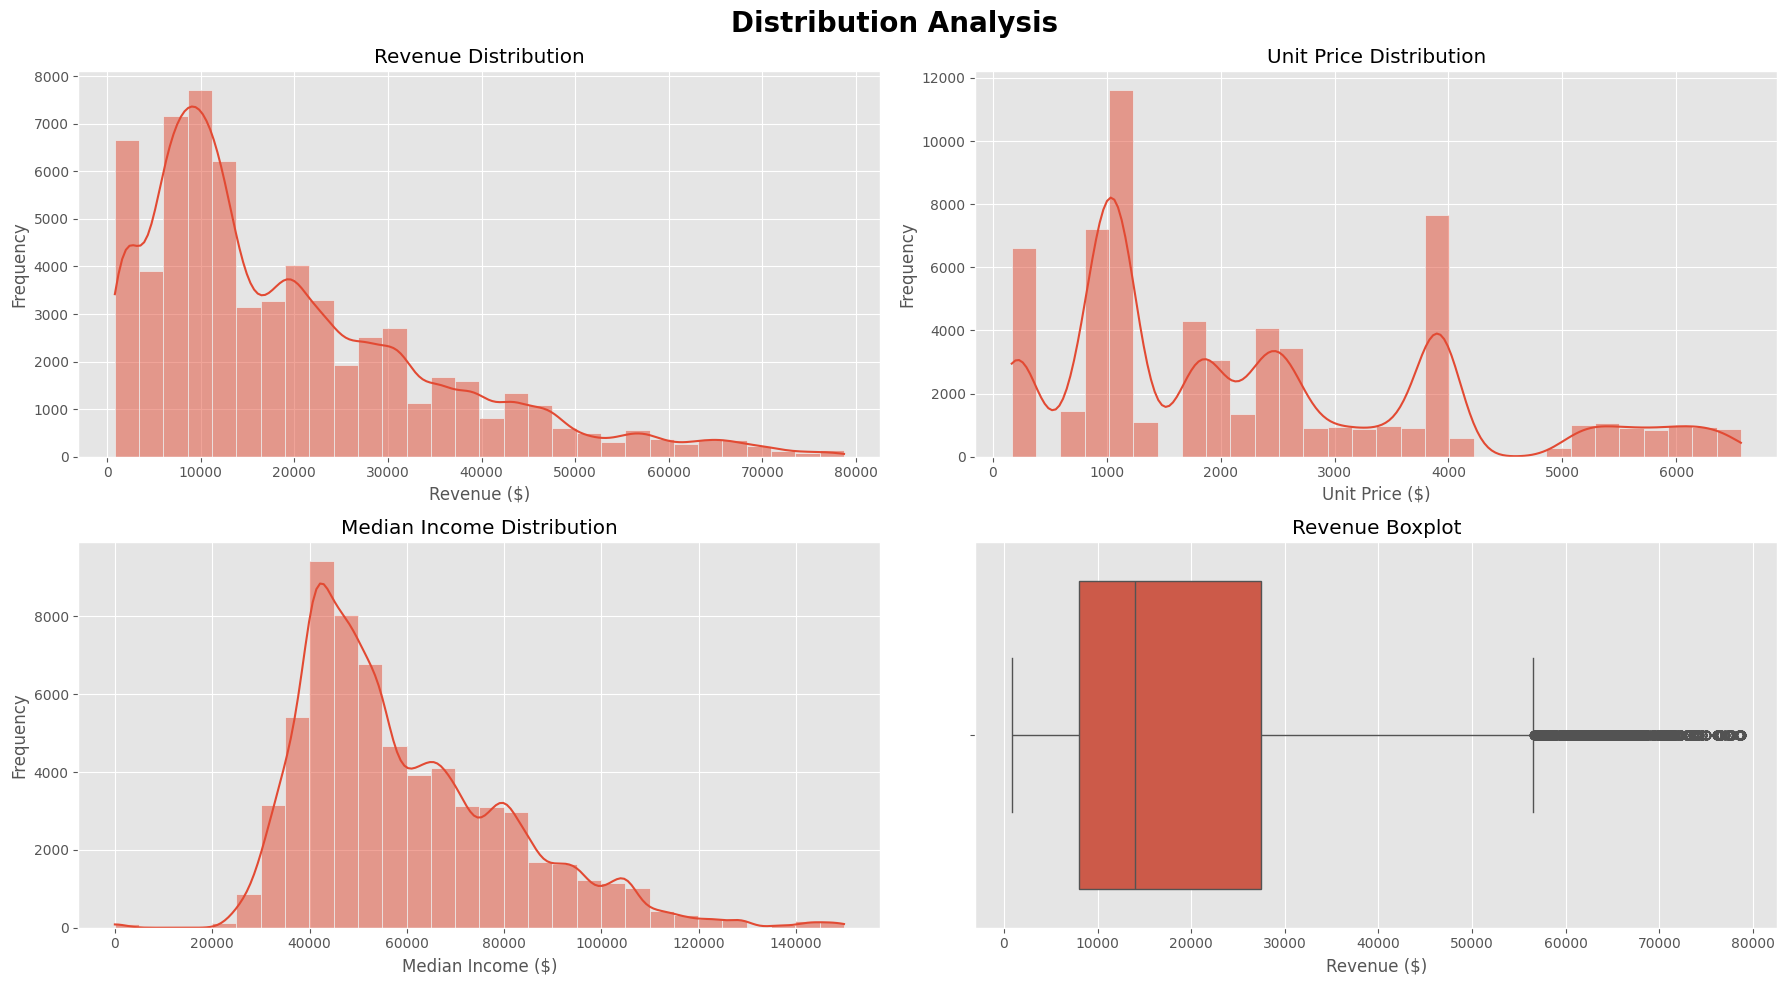

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Distribution Analysis", fontsize=20, fontweight='bold')

# Revenue Distribution
sns.histplot(df2['Revenue'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("Revenue Distribution")
axes[0,0].set_xlabel("Revenue ($)")
axes[0,0].set_ylabel("Frequency")

# Unit Price Distribution
sns.histplot(df2['unit_price'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Unit Price Distribution")
axes[0,1].set_xlabel("Unit Price ($)")
axes[0,1].set_ylabel("Frequency")

# Median Income Distribution
sns.histplot(df2['median_income'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Median Income Distribution")
axes[1,0].set_xlabel("Median Income ($)")
axes[1,0].set_ylabel("Frequency")

# Revenue Boxplot
sns.boxplot(x=df2['Revenue'], ax=axes[1,1])
axes[1,1].set_title("Revenue Boxplot")
axes[1,1].set_xlabel("Revenue ($)")
axes[1,1].set_ylabel("")

plt.tight_layout()
plt.show()

Revenue Distribution

Observation:- 
The revenue distribution is right-skewed (positively skewed).
Most orders generate low to medium revenue.
A small number of orders generate very high revenue.

Business Insight:- 
A few high-value orders contribute significantly to total revenue.
The business should identify these high-value customers/products and focus on retaining them.

Unit Price Distribution

Observation:- 
Products are concentrated around a few specific price points.
There appear to be multiple pricing clusters rather than a smooth distribution.

Business Insight:-
Products are likely grouped into pricing tiers.
This may represent different product categories or pricing strategies.


Median Income Distribution

Observation:-
Most customers belong to areas with median incomes between approximately $40,000 and $80,000.
Very few customers come from extremely low- or high-income regions.

Business Insight:- 
The company's customer base is concentrated in middle-income areas.
Marketing campaigns could be tailored toward these regions.

Revenue Boxplot

Observation:-
Revenue contains numerous high-value outliers.
The median revenue is much lower than the maximum revenue.

Business Insight:-
A small percentage of transactions generate exceptionally high revenue.

Order Analysis

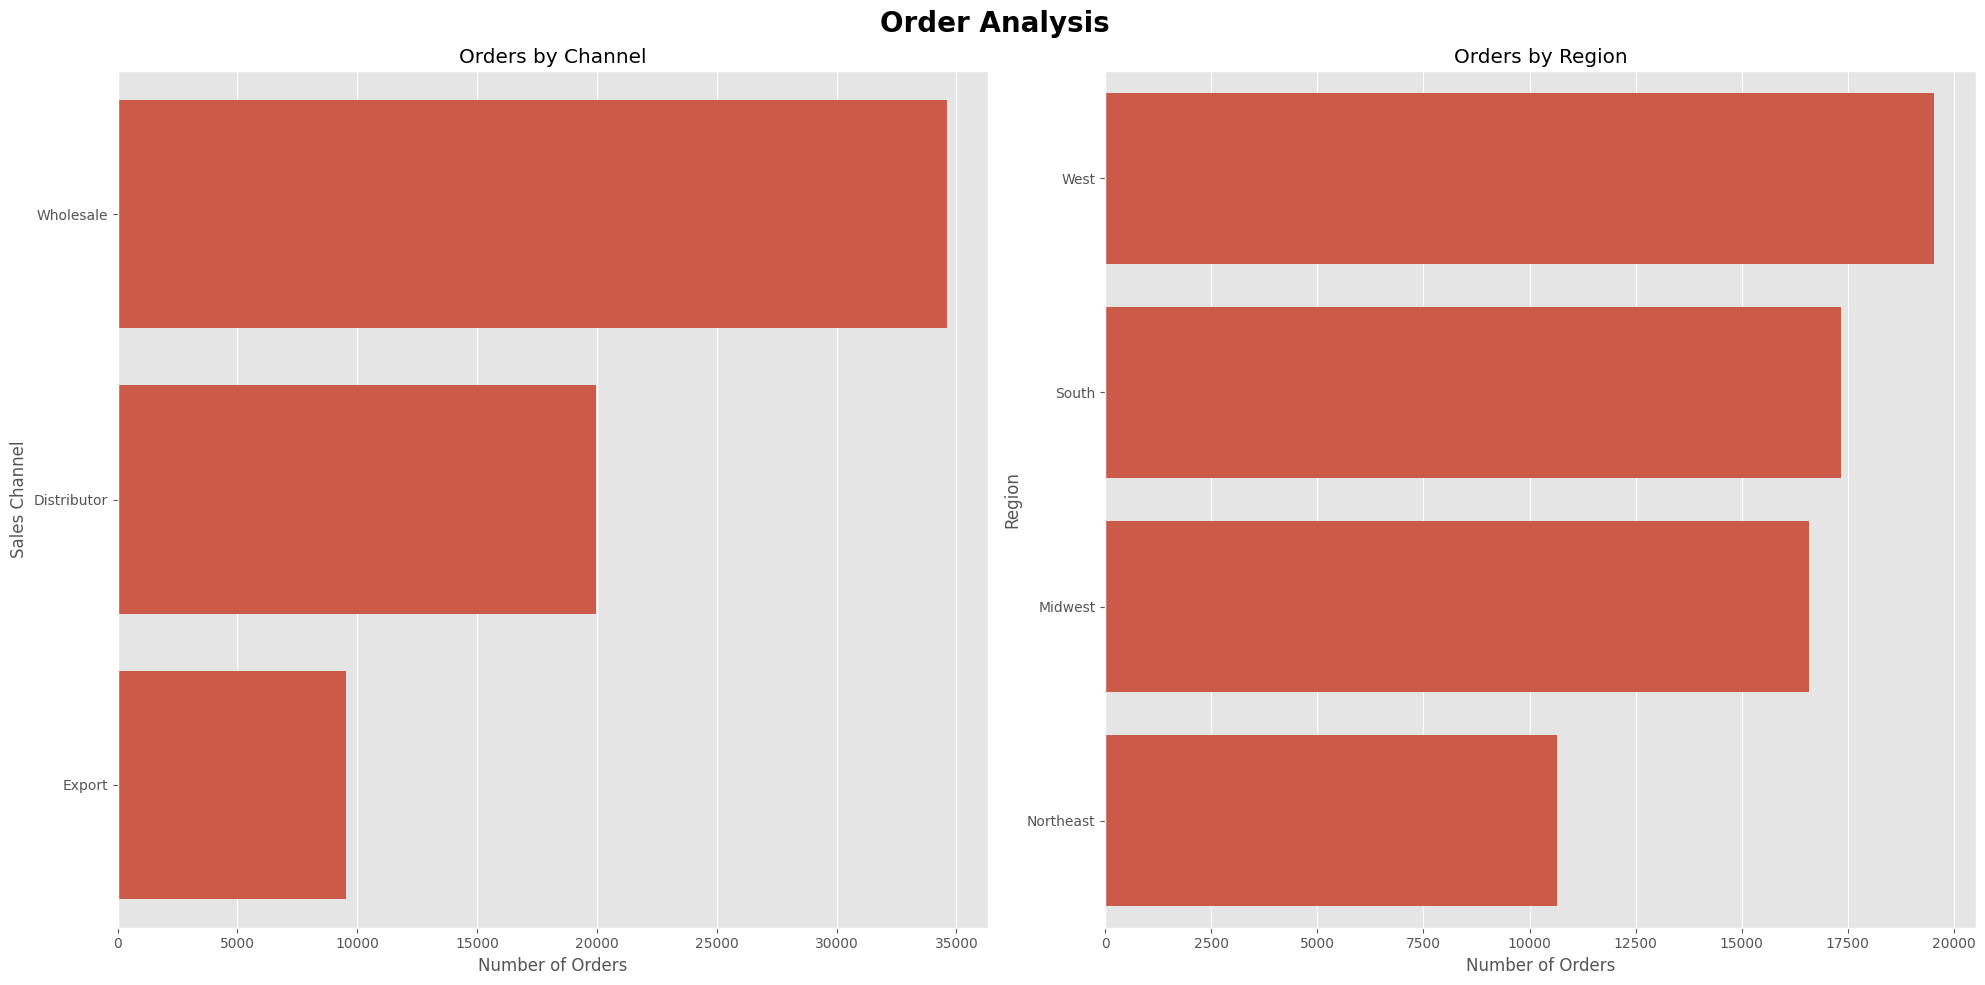

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Order Analysis", fontsize=20, fontweight='bold')

# Orders by Channel
sns.countplot(
    data=df2,
    y='channel',
    order=df2['channel'].value_counts().index,
    ax=axes[0]
)
axes[0,].set_title("Orders by Channel")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Sales Channel")

# Orders by Region
sns.countplot(
    data=df2,
    y='region',
    order=df2['region'].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Orders by Region")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.show()

Orders by Channel

Observation:- 
Wholesale is the dominant sales channel.
Distributor contributes a moderate number of orders.
Export represents the smallest share.

Business Insight:- 
Wholesale is the company's primary revenue channel.
Export sales could be explored for growth opportunities.

Orders by Region

Observation:- 
The West region has the highest number of orders.
Northeast has the lowest.

Business Insight:- 
Customer demand is strongest in the West.
Marketing efforts or operational improvements may be needed in the Northeast.

Revenue Analysis

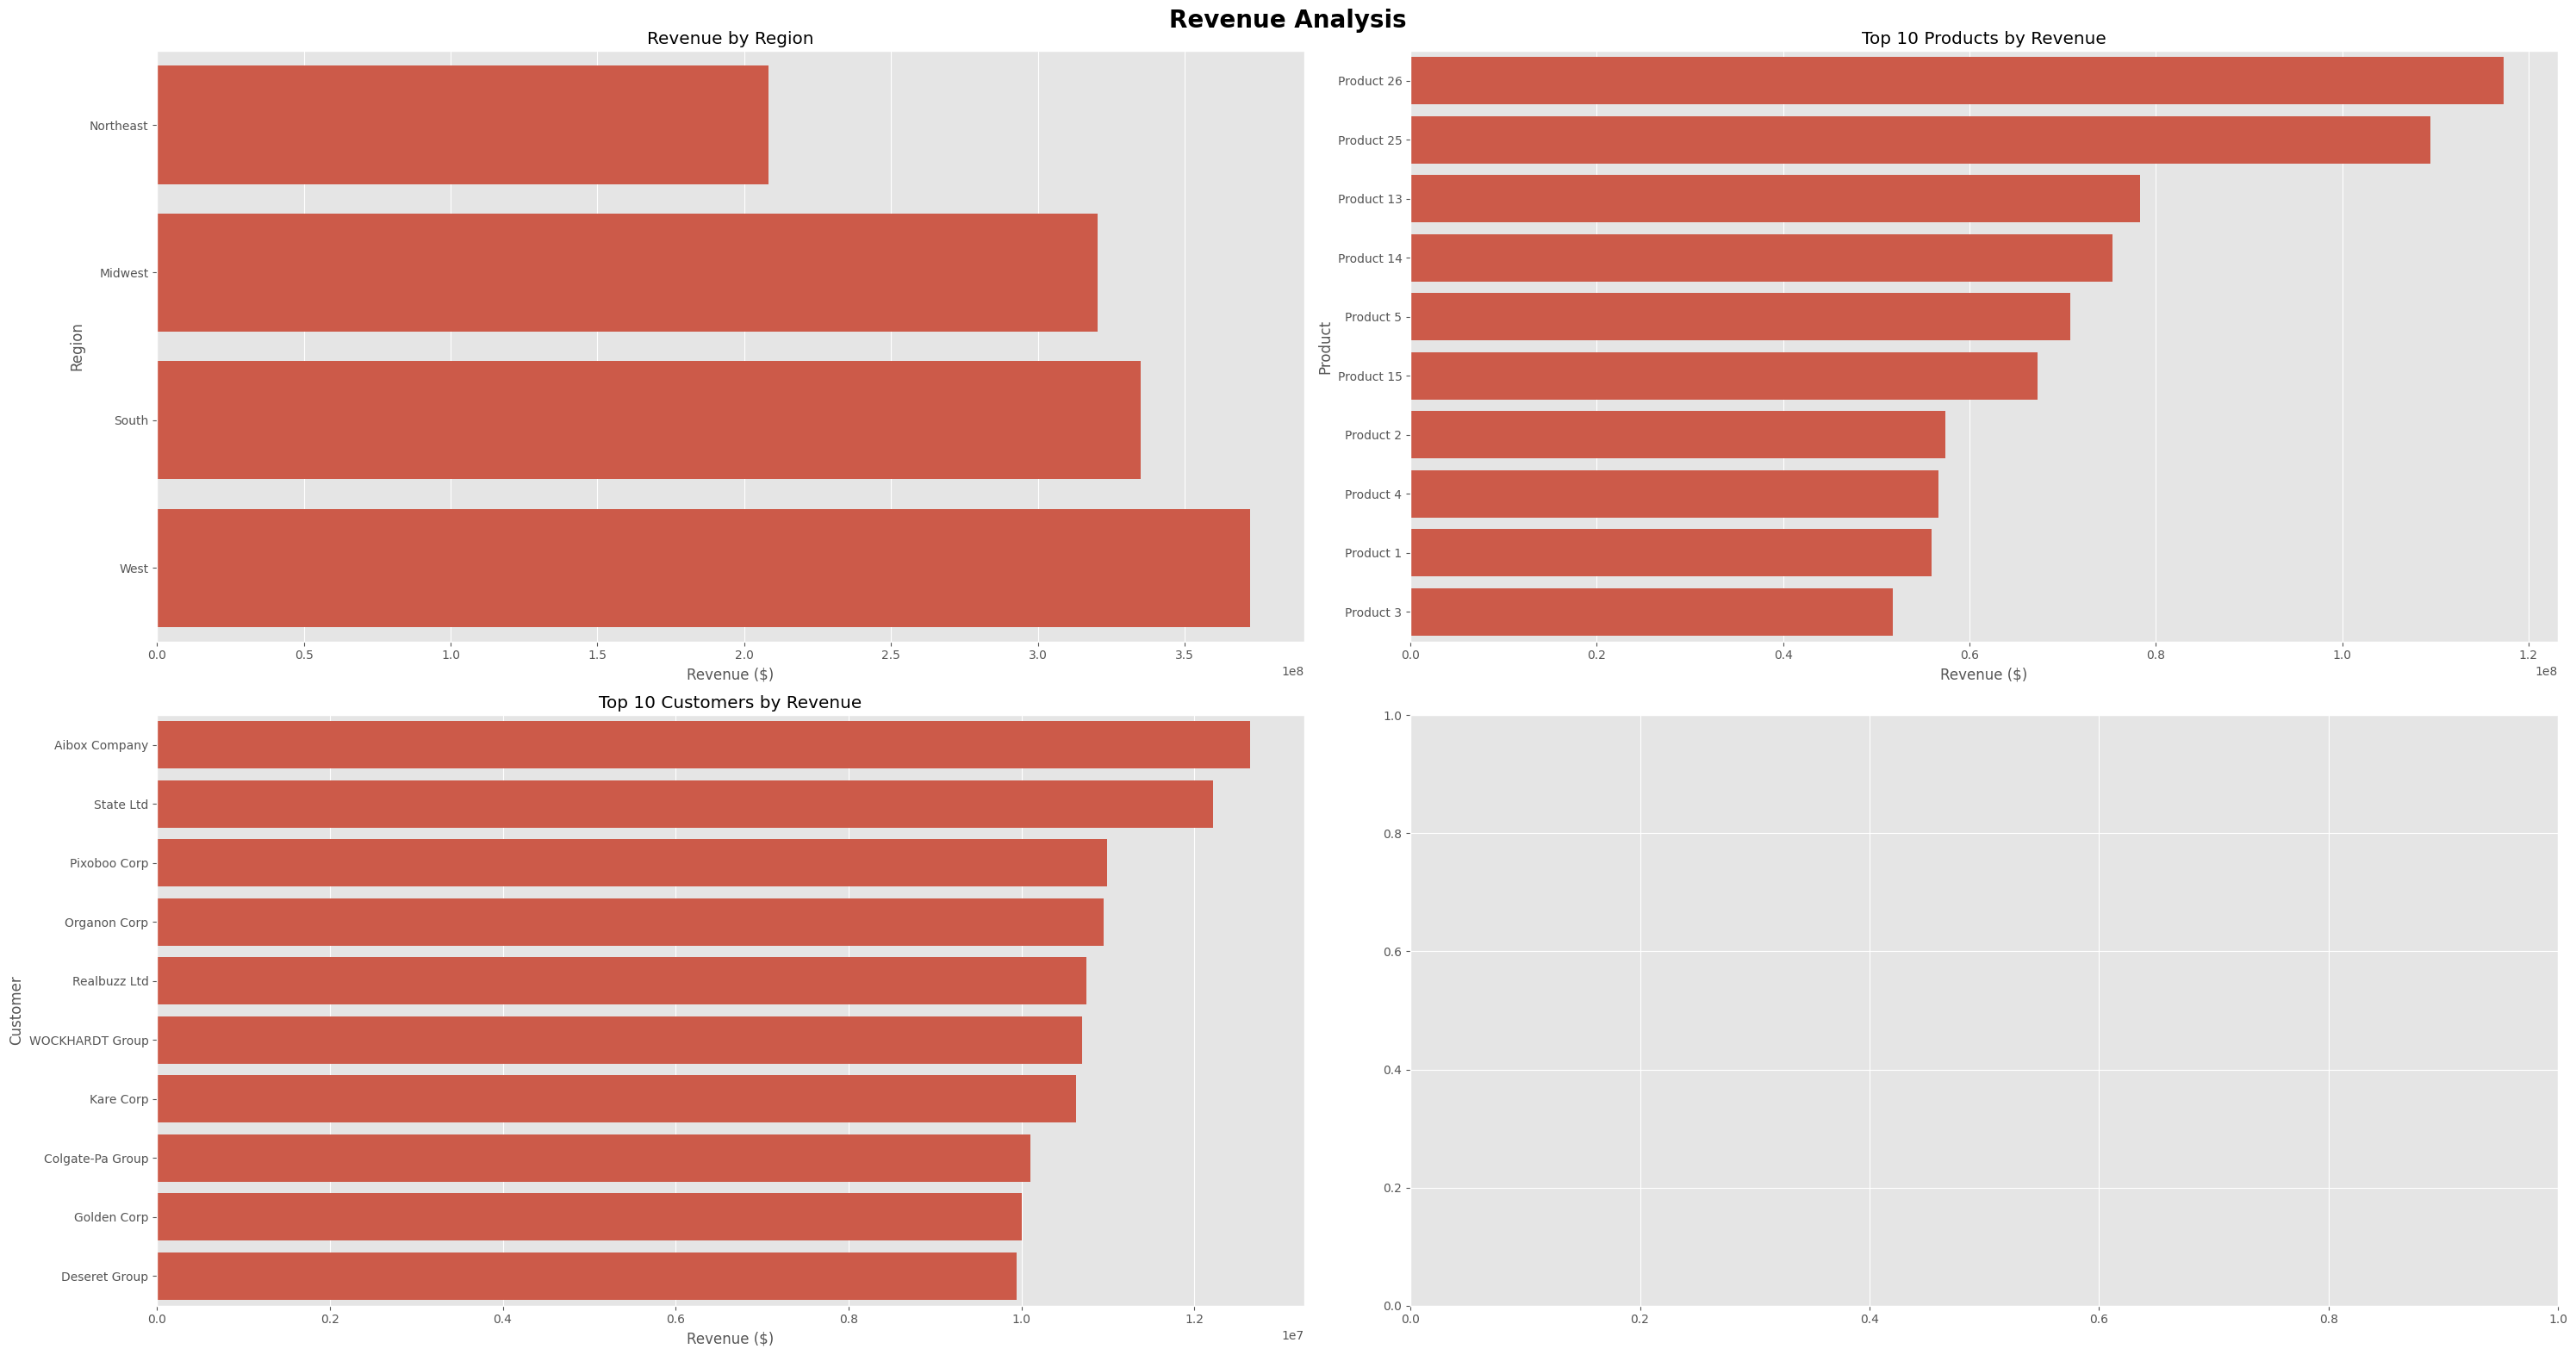

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(30, 16))
fig.suptitle("Revenue Analysis", fontsize=20, fontweight='bold')

# Revenue by Region
region_rev = df2.groupby('region')['Revenue'].sum().sort_values()

sns.barplot(
    x=region_rev.values,
    y=region_rev.index,
    ax=axes[0,0]
)
axes[0,0].set_title("Revenue by Region")
axes[0,0].set_xlabel("Revenue ($)")
axes[0,0].set_ylabel("Region")

# Top 10 Products
top_products = (
    df2.groupby('product_name')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    ax=axes[0,1]
)
axes[0,1].set_title("Top 10 Products by Revenue")
axes[0,1].set_xlabel("Revenue ($)")
axes[0,1].set_ylabel("Product")

# Top 10 Customers
top_customers = (
    df2.groupby('customer_names')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    ax=axes[1,0]
)
axes[1,0].set_title("Top 10 Customers by Revenue")
axes[1,0].set_xlabel("Revenue ($)")
axes[1,0].set_ylabel("Customer")

plt.tight_layout()
plt.show()

Revenue by Region

Observation:- 
West generates the highest revenue.
Northeast contributes the least revenue.

Business Insight:-
Revenue follows a similar pattern to order volume.
The West region should remain a strategic focus.
The Northeast may require targeted promotions to increase sales.

Top Products by Revenue

Observation:-
Product 26 is the highest revenue-generating product.
Revenue gradually decreases across the remaining top products.

Business Insight:- 
Revenue is concentrated among a few products.
Ensure sufficient inventory for these top-performing products.
Analyze why lower-performing products underperform.

Top Customers by Revenue

Observation:- 
A few customers contribute a significant portion of revenue.

Business Insight:- 
Customer revenue follows the Pareto Principle (80/20 rule), where a relatively small group of customers contributes a large share of total revenue.

Time Series Analysis

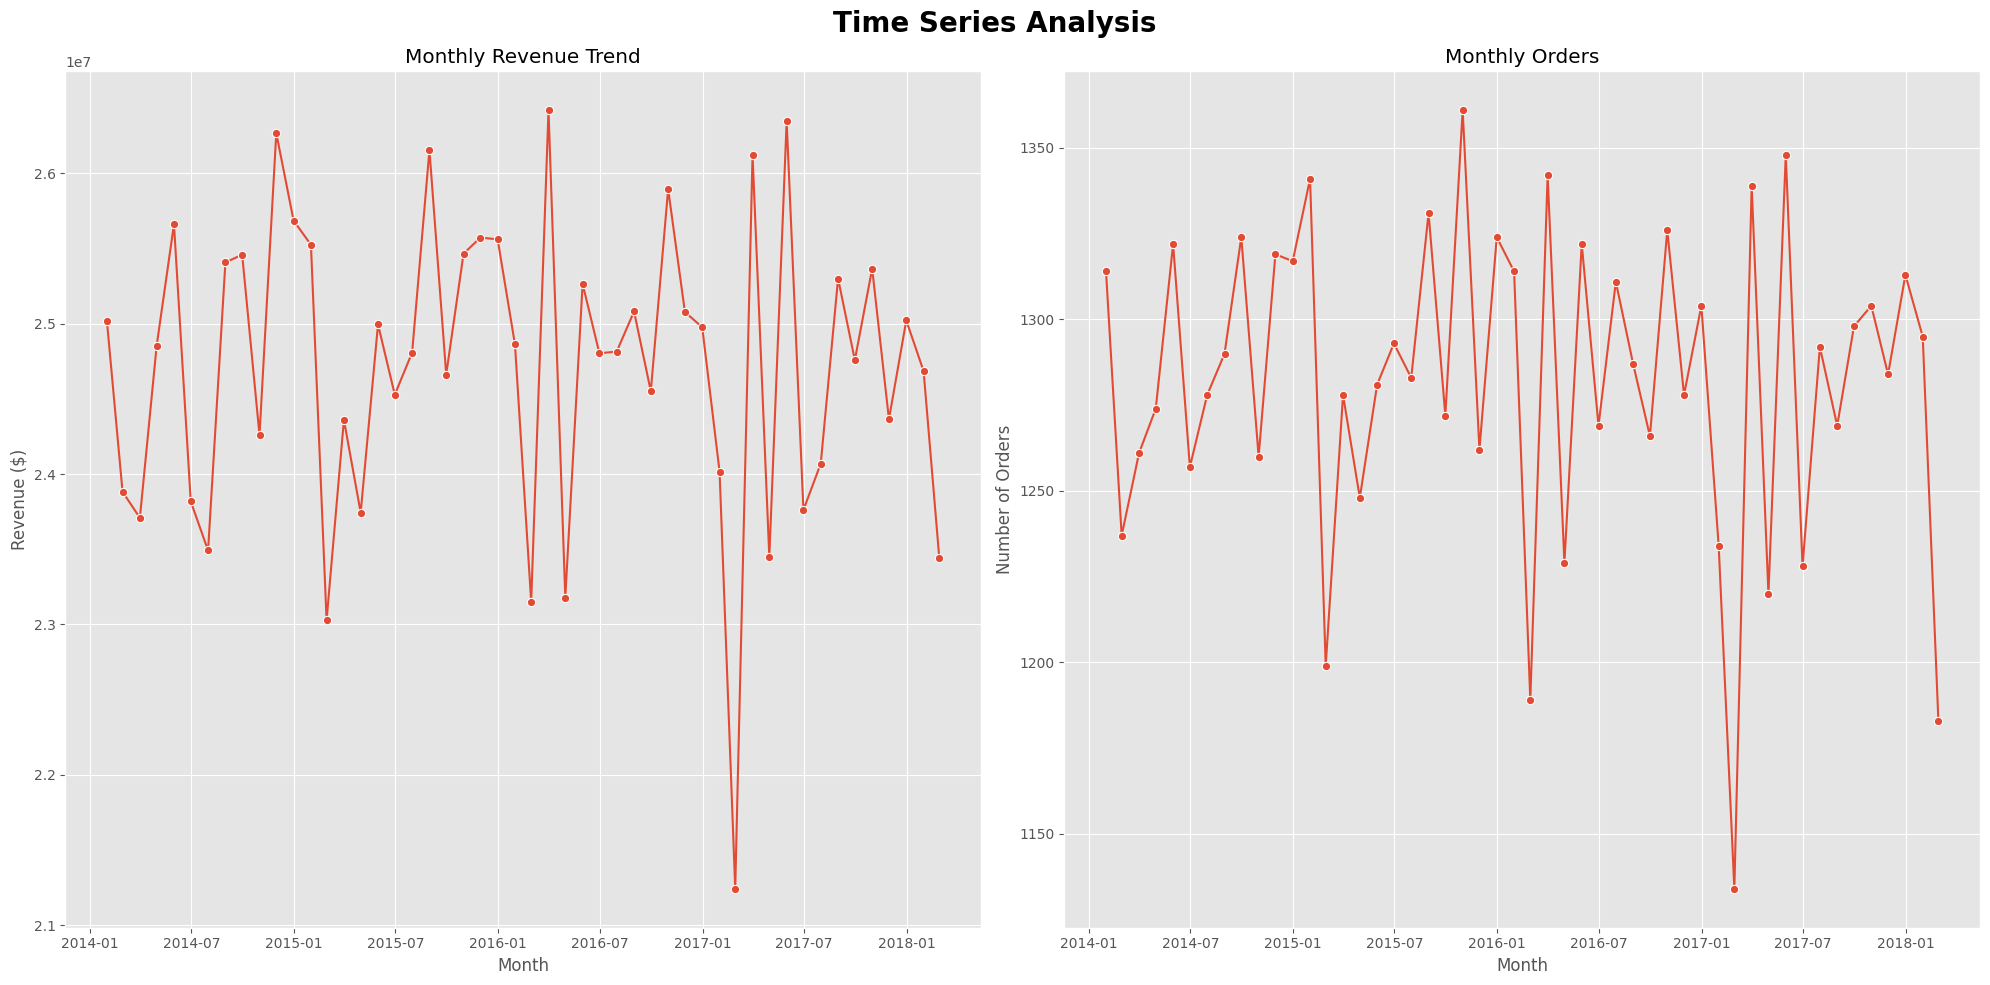

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Time Series Analysis", fontsize=20, fontweight='bold')

# Monthly Revenue Trend
monthly_revenue = df2.groupby(pd.Grouper(key='orderdate', freq='ME'))['Revenue'].sum()

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker='o',
    ax=axes[0]
)
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue ($)")

# Monthly Orders
monthly_orders = df2.groupby(pd.Grouper(key='orderdate', freq='ME'))['ordernumber'].count()

sns.lineplot(
    x=monthly_orders.index,
    y=monthly_orders.values,
    marker='o',
    ax=axes[1]
)
axes[1].set_title("Monthly Orders")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

Monthly Revenue Trend

Observation:-
Monthly revenue remains relatively stable.
There are no clear long-term upward or downward trends.
A noticeable drop occurs around early 2017.

Business Insight:-
Sales appear consistent over time.
Investigate the sharp decline in early 2017—it could be due to seasonality, supply issues, or data anomalies.

Monthly Orders

Observation:-
Order volume fluctuates slightly but remains generally stable.
The drop in order count aligns with the revenue dip.

Business Insight:-
Revenue fluctuations are likely driven by changes in order volume rather than pricing.

Bivariate Analysis

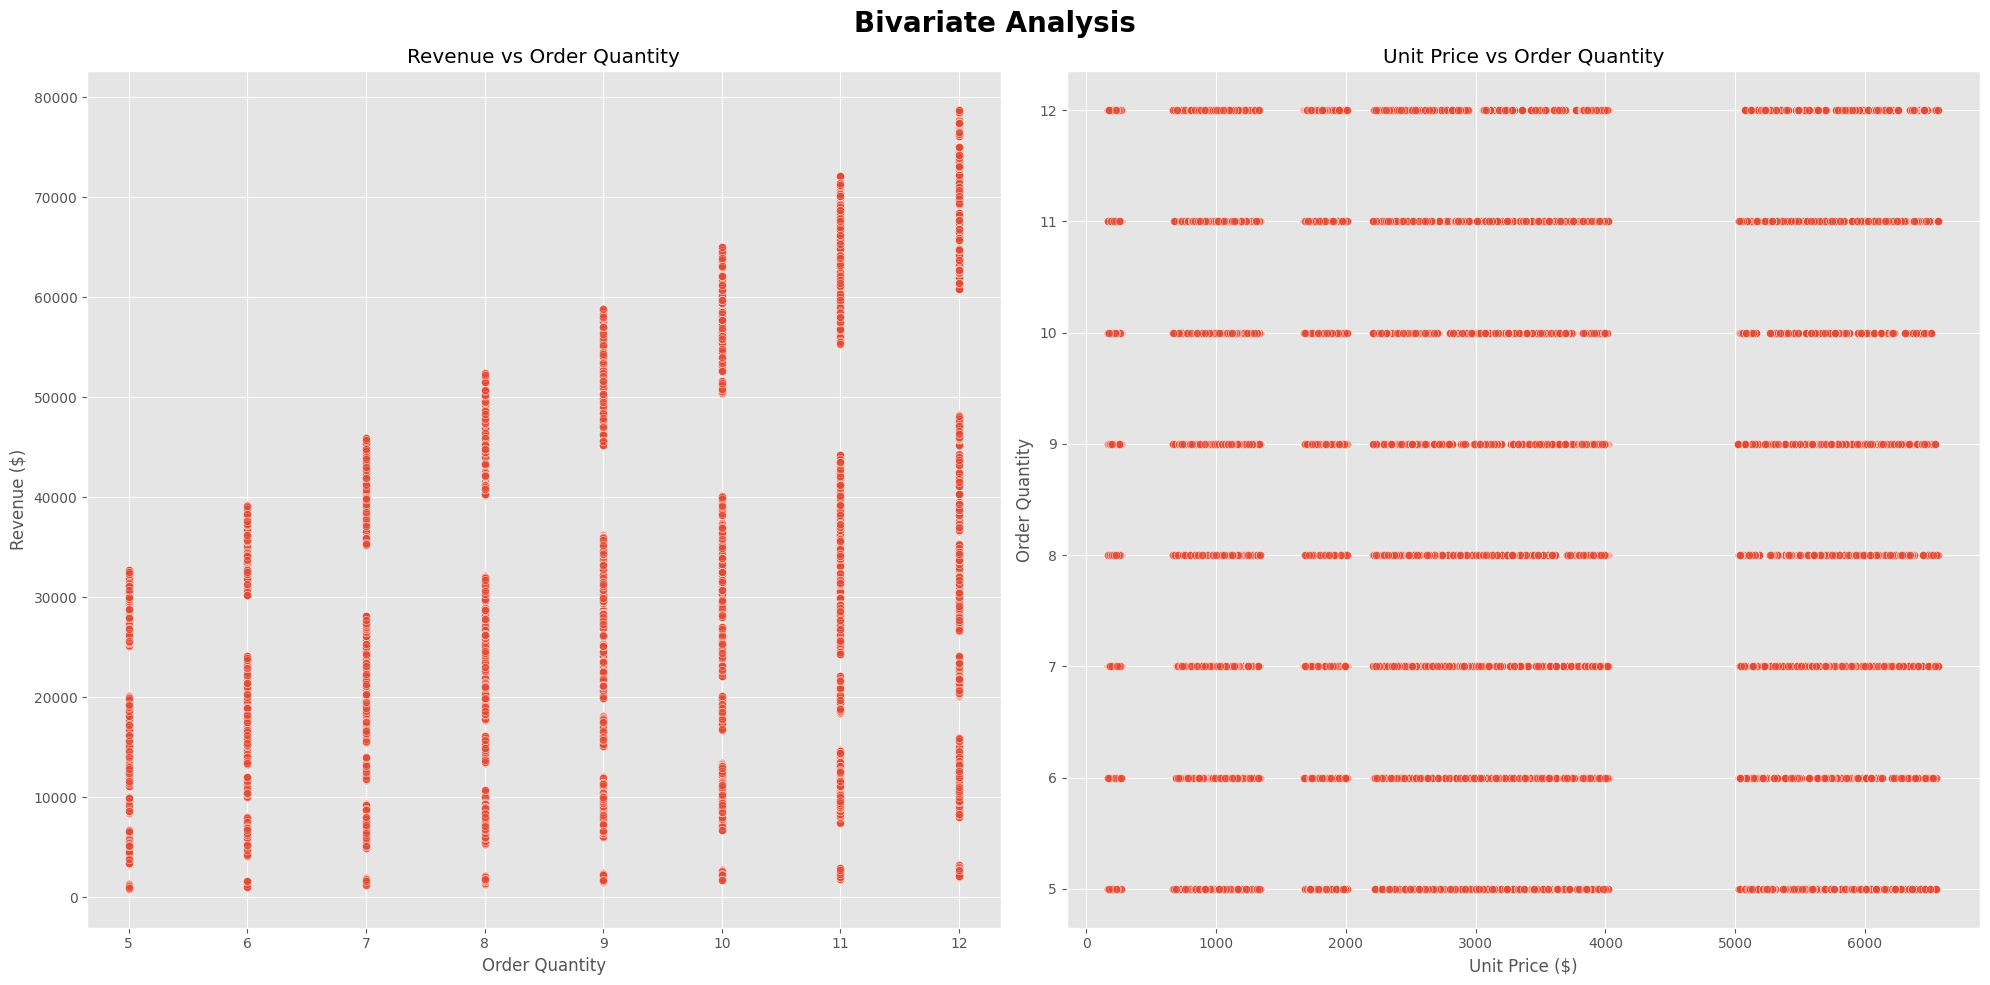

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Bivariate Analysis", fontsize=20, fontweight='bold')

# Revenue vs Order Quantity
sns.scatterplot(
    data=df2,
    x='order_quantity',
    y='Revenue',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Revenue vs Order Quantity")
axes[0].set_xlabel("Order Quantity")
axes[0].set_ylabel("Revenue ($)")

# Unit Price vs Order Quantity
sns.scatterplot(
    data=df2,
    x='unit_price',
    y='order_quantity',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Unit Price vs Order Quantity")
axes[1].set_xlabel("Unit Price ($)")
axes[1].set_ylabel("Order Quantity")

plt.tight_layout()
plt.show()

Revenue vs Order Quantity

Observation:-
Revenue generally increases as order quantity increases.
Higher order quantities are associated with higher revenue values.

Business Insight:-
Encouraging customers to purchase larger quantities (e.g., through bulk discounts) could increase revenue.

Unit Price vs Order Quantity

Observation:- 
There is no clear relationship between unit price and order quantity.
Customers purchase similar quantities across different price ranges.

Business Insight:-
Order quantity does not appear to be strongly influenced by product price.
Pricing changes may not significantly impact purchase quantity.

Correlation Analysis

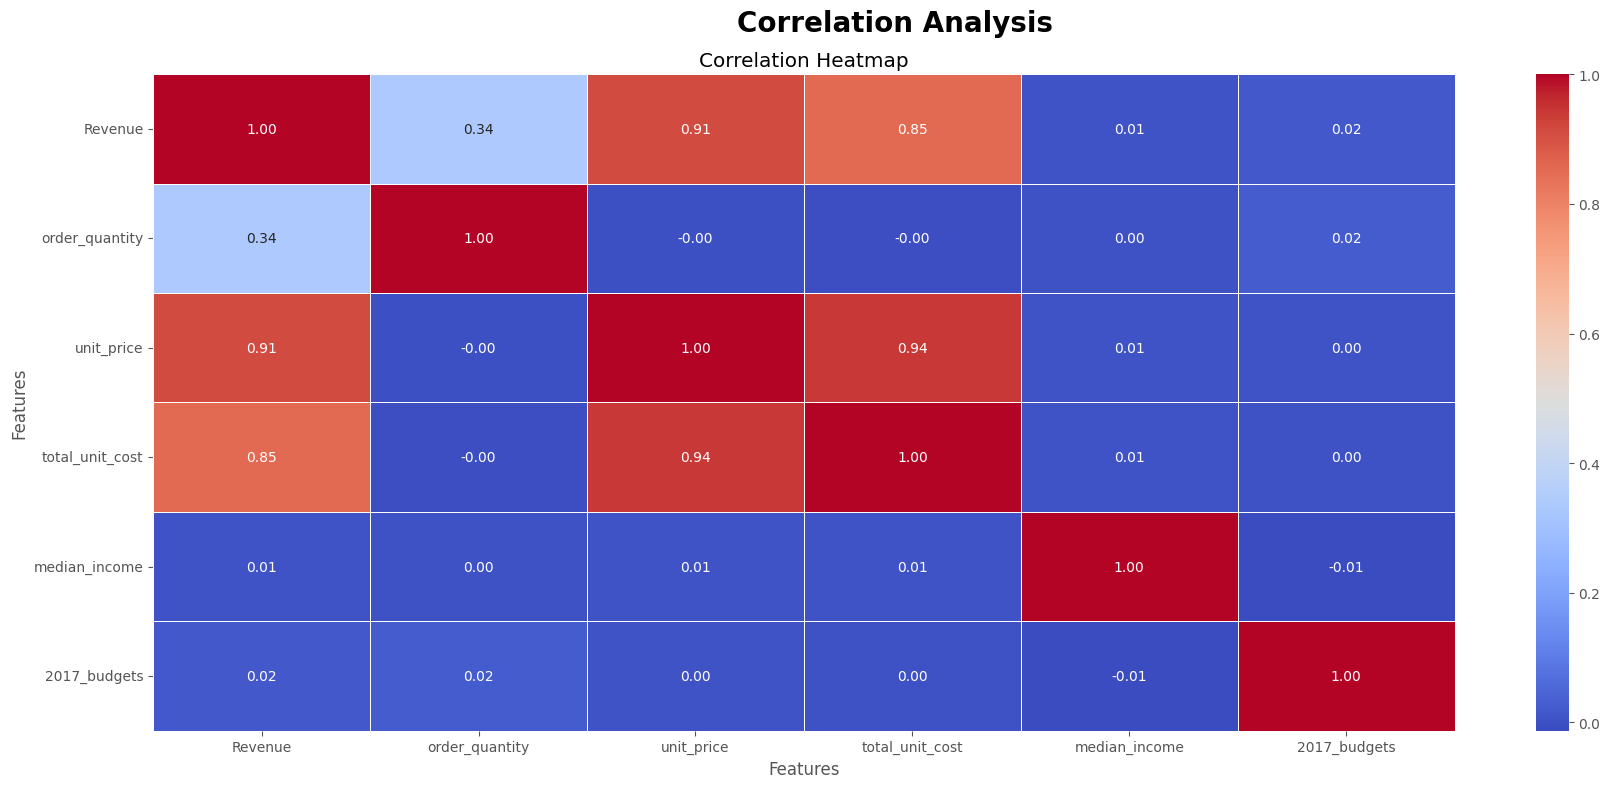

In [97]:
fig, ax = plt.subplots(figsize=(18,8))
fig.suptitle("Correlation Analysis", fontsize=20, fontweight='bold')

numeric_cols = [
    'Revenue',
    'order_quantity',
    'unit_price',
    'total_unit_cost',
    'median_income',
    '2017_budgets'
]

corr = df2[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Heatmap")
ax.set_xlabel("Features")
ax.set_ylabel("Features")

plt.tight_layout()
plt.show()

The heatmap provides several useful insights:

Strong Positive Correlations

Variables	             Correlation	         Insight
Revenue ↔ Unit Price	      0.91	     Higher-priced products generate higher revenue.
Revenue ↔ Total Unit Cost	  0.85	     More expensive products naturally have higher costs.
Unit Price ↔ Total Unit Cost  0.94	     Product cost increases alongside selling price.

Moderate Correlation

Variables	               Correlation
Revenue ↔ Order Quantity	0.34

Business Insight:-

Revenue is influenced by both:
product price, and
order quantity,

but unit price has a stronger relationship with revenue in this dataset.

Weak Correlations

Median Income shows almost no correlation with:

Revenue
Unit Price
Order Quantity
Business Insight

Customers from higher-income areas do not necessarily generate higher sales. Other factors, such as product demand, marketing effectiveness, or sales channel, are likely more important drivers of revenue.

Executive Summary

1) Wholesale is the dominant sales channel, while Export contributes the fewest orders.

2) The West region leads in both order volume and revenue, making it the strongest-performing market.

3) Revenue is concentrated among a small number of products and customers, suggesting opportunities to strengthen relationships with key accounts and maintain stock for top-selling products.

4) Monthly sales remain relatively stable, with one noticeable decline around early 2017 that merits further investigation.

5) Revenue is driven more by product pricing than by order quantity, as shown by the strong correlation between unit price and revenue.

6) Median income has little impact on sales performance, indicating that geographic income levels alone are not a reliable predictor of revenue.